In [2]:
import pandas as pd

train = pd.read_csv("../data/train_FD001.txt",
                    sep=r"\s+",
                    header=None)

train.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
columns = [
    "unit_number",
    "time_cycles",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3",
]

columns += [f"sensor_{i}" for i in range(1, 22)]

train.columns = columns

In [4]:
train.head()

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [5]:
train.shape

(20631, 26)

In [6]:
train["unit_number"].nunique()

100

In [7]:
train.groupby("unit_number")["time_cycles"].max().reset_index().head(7)

,unit_number,time_cycles
0,1,192
1,2,287
2,3,179
3,4,189
4,5,269
5,6,188
6,7,259


In [8]:
max_cycles=train.groupby("unit_number")["time_cycles"].transform("max")
train["RUL"] = max_cycles - train["time_cycles"]

In [9]:
train.head()

,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [10]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
unit_number,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
time_cycles,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
op_setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
op_setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
op_setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,1.776400e-15,14.6200,14.6200,14.6200,14.6200,14.6200


In [11]:
train.nunique().sort_values()

sensor_18          1
sensor_10          1
sensor_16          1
op_setting_3       1
sensor_1           1
sensor_19          1
sensor_5           1
sensor_6           2
op_setting_2      13
sensor_17         13
sensor_8          53
sensor_13         56
unit_number      100
sensor_20        120
op_setting_1     158
sensor_11        159
sensor_2         310
RUL              362
time_cycles      362
sensor_12        427
sensor_7         513
sensor_15       1918
sensor_3        3012
sensor_4        4051
sensor_21       4745
sensor_14       6078
sensor_9        6403
dtype: int64

In [12]:
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]

train[sensor_cols].std().sort_values()

sensor_1     0.000000e+00
sensor_19    0.000000e+00
sensor_18    0.000000e+00
sensor_10    0.000000e+00
sensor_16    1.387812e-17
sensor_5     1.776400e-15
sensor_6     1.388985e-03
sensor_15    3.750504e-02
sensor_8     7.098548e-02
sensor_13    7.191892e-02
sensor_21    1.082509e-01
sensor_20    1.807464e-01
sensor_11    2.670874e-01
sensor_2     5.000533e-01
sensor_12    7.375534e-01
sensor_7     8.850923e-01
sensor_17    1.548763e+00
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_14    1.907618e+01
sensor_9     2.208288e+01
dtype: float64

In [31]:
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]

correlation = train[sensor_cols + ["RUL"]].corr()["RUL"].sort_values()

print(correlation)

sensor_11   -0.696228
sensor_4    -0.678948
sensor_15   -0.642667
sensor_2    -0.606484
sensor_17   -0.606154
sensor_3    -0.584520
sensor_8    -0.563968
sensor_13   -0.562569
sensor_9    -0.390102
sensor_14   -0.306769
sensor_6    -0.128348
sensor_20    0.629428
sensor_21    0.635662
sensor_7     0.657223
sensor_12    0.671983
RUL          1.000000
sensor_1          NaN
sensor_5          NaN
sensor_10         NaN
sensor_16         NaN
sensor_18         NaN
sensor_19         NaN
Name: RUL, dtype: float64


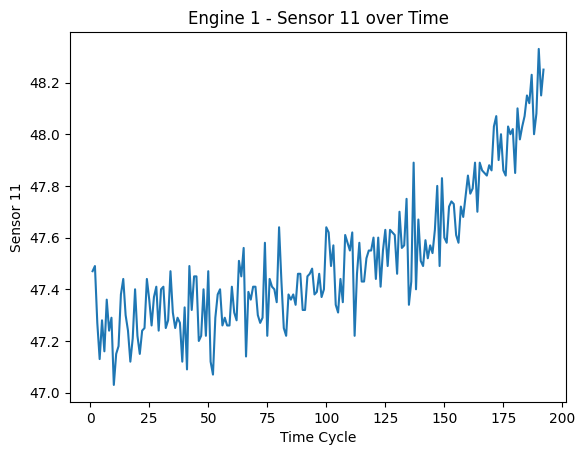

In [14]:
import matplotlib.pyplot as plt

engine_1 = train[train["unit_number"] == 1]

plt.plot(
    engine_1["time_cycles"],
    engine_1["sensor_11"]
)

plt.xlabel("Time Cycle")
plt.ylabel("Sensor 11")
plt.title("Engine 1 - Sensor 11 over Time")

plt.show()

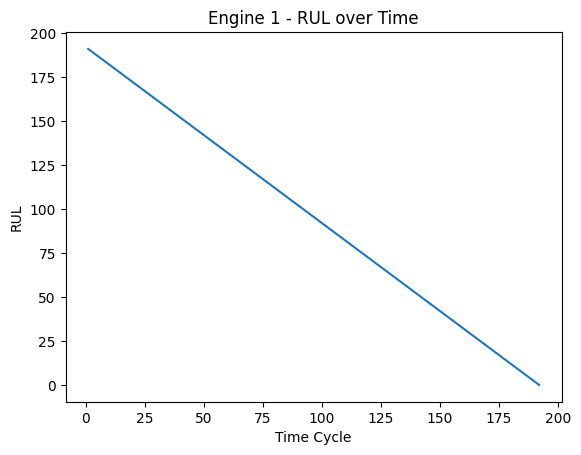

In [15]:
plt.plot(
    engine_1["time_cycles"],
    engine_1["RUL"]
)

plt.xlabel("Time Cycle")
plt.ylabel("RUL")
plt.title("Engine 1 - RUL over Time")

plt.show()

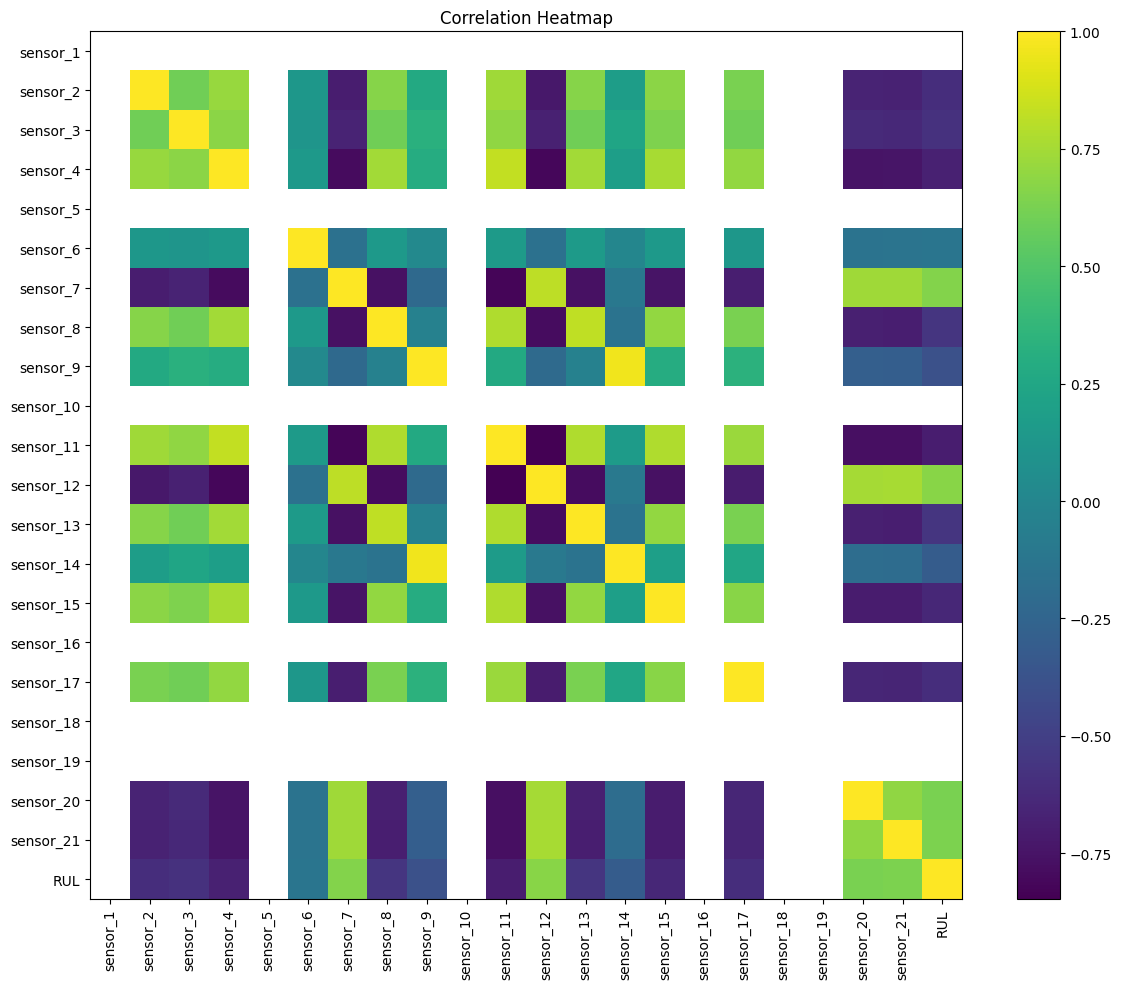

In [16]:
import matplotlib.pyplot as plt

corr_matrix = train[sensor_cols + ["RUL"]].corr()

plt.figure(figsize=(12, 10))

plt.imshow(corr_matrix, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [17]:
import numpy as np

sensor_corr = train[sensor_cols].corr()

# ناخد النصف العلوي فقط عشان منكررش نفس الزوج
upper = sensor_corr.where(
    np.triu(np.ones(sensor_corr.shape), k=1).astype(bool)
)

pairs = (
    upper.stack()
    .reset_index()
)

pairs.columns = ["sensor1", "sensor2", "correlation"]

pairs["abs_correlation"] = pairs["correlation"].abs()

pairs = pairs.sort_values(
    "abs_correlation",
    ascending=False
)

print(pairs.head(20))

      sensor1    sensor2  correlation  abs_correlation
72   sensor_9  sensor_14     0.963157         0.963157
77  sensor_11  sensor_12    -0.846884         0.846884
31   sensor_4  sensor_11     0.830136         0.830136
63   sensor_8  sensor_13     0.826084         0.826084
52   sensor_7  sensor_11    -0.822805         0.822805
32   sensor_4  sensor_12    -0.815591         0.815591
53   sensor_7  sensor_12     0.812713         0.812713
28   sensor_4   sensor_7    -0.793130         0.793130
84  sensor_12  sensor_13    -0.788441         0.788441
62   sensor_8  sensor_12    -0.786540         0.786540
61   sensor_8  sensor_11     0.782213         0.782213
80  sensor_11  sensor_15     0.780913         0.780913
78  sensor_11  sensor_13     0.780761         0.780761
83  sensor_11  sensor_21    -0.772554         0.772554
82  sensor_11  sensor_20    -0.771510         0.771510
50   sensor_7   sensor_8    -0.767132         0.767132
86  sensor_12  sensor_15    -0.766052         0.766052
54   senso

In [18]:
sensor_rul_corr = (
    train[sensor_cols + ["RUL"]]
    .corr()["RUL"]
    .drop("RUL")
    .dropna()
    .to_frame("RUL_correlation")
)

sensor_rul_corr["abs_correlation"] = (
    sensor_rul_corr["RUL_correlation"].abs()
)

sensor_rul_corr = sensor_rul_corr.sort_values(
    "abs_correlation",
    ascending=False
)

print(sensor_rul_corr)

           RUL_correlation  abs_correlation
sensor_11        -0.696228         0.696228
sensor_4         -0.678948         0.678948
sensor_12         0.671983         0.671983
sensor_7          0.657223         0.657223
sensor_15        -0.642667         0.642667
sensor_21         0.635662         0.635662
sensor_20         0.629428         0.629428
sensor_2         -0.606484         0.606484
sensor_17        -0.606154         0.606154
sensor_3         -0.584520         0.584520
sensor_8         -0.563968         0.563968
sensor_13        -0.562569         0.562569
sensor_9         -0.390102         0.390102
sensor_14        -0.306769         0.306769
sensor_6         -0.128348         0.128348


In [22]:
important_sensors = [
    "sensor_11",
    "sensor_4",
    "sensor_12",
    "sensor_7",
    "sensor_15"
]

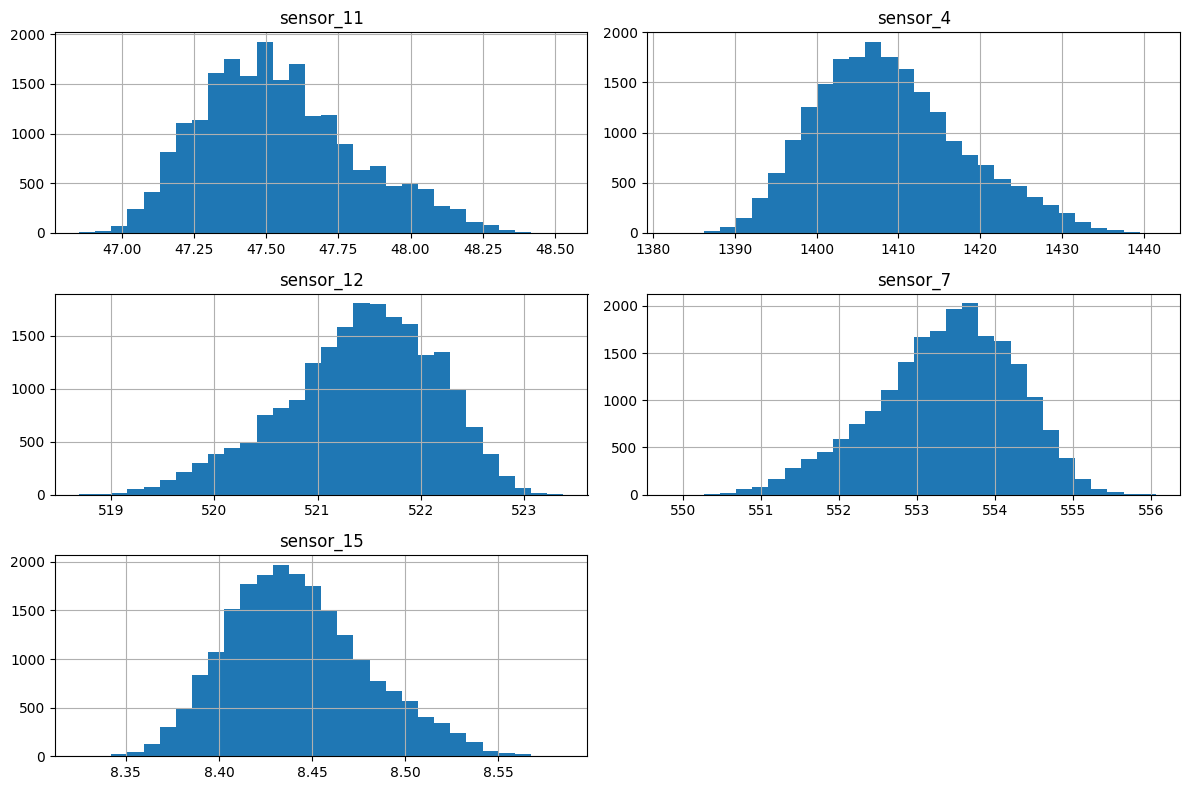

In [26]:
train[important_sensors].hist(
    figsize=(12, 8),
    bins=30
)

plt.tight_layout()
plt.show()

In [ ]:
train[important_sensors].skew()

sensor_11    0.469329
sensor_4     0.443194
sensor_12   -0.442407
sensor_7    -0.394329
sensor_15    0.388259
dtype: float64

In [28]:
train[important_sensors].describe()

,sensor_11,sensor_4,sensor_12,sensor_7,sensor_15
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.000000
mean,47.541168,1408.933782,521.413470,553.367711,8.442146
std,0.267087,9.000605,0.737553,0.885092,0.037505
min,46.850000,1382.250000,518.690000,549.850000,8.324900
25%,47.350000,1402.360000,520.960000,552.810000,8.414900
50%,47.510000,1408.040000,521.480000,553.440000,8.438900
75%,47.700000,1414.555000,521.950000,554.010000,8.465600
max,48.530000,1441.490000,523.380000,556.060000,8.584800


In [29]:
constant_cols = [
    col for col in train.columns
    if train[col].nunique() <= 1
]

print(constant_cols)

['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']


In [46]:
feature_cols = [
    col for col in train.columns
    if col not in constant_cols + ["RUL", "unit_number"]
]
print(feature_cols)

['time_cycles', 'op_setting_1', 'op_setting_2', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


In [37]:
from sklearn.model_selection import train_test_split

engine_ids = train["unit_number"].unique()

train_engines, val_engines = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

print("Training engines:", len(train_engines))
print("Validation engines:", len(val_engines))

Training engines: 80
Validation engines: 20


In [38]:
train_data = train[train["unit_number"].isin(train_engines)].copy()
val_data = train[train["unit_number"].isin(val_engines)].copy()

print("Train shape:", train_data.shape)
print("Validation shape:", val_data.shape)

Train shape: (16561, 27)
Validation shape: (4070, 27)


In [44]:
X_train = train_data[feature_cols]
y_train = train_data["RUL"]

X_val = val_data[feature_cols]
y_val = val_data["RUL"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train: (16561, 18)
y_train: (16561,)
X_val: (4070, 18)
y_val: (4070,)
